# 미국 수출품목 증가율 조회 V4

한국 수출품목 분석 노트북(`한국_수출품목_증가율_조회_v6.ipynb`)과 동일한 수준의 분석을
미국 데이터(`us_trade_export_monthly_with_forecast`, HS 코드별 실측 `expDlr` + 예측 `expDlr_forecast`,
`is_forecast` 플래그, `created_at`/`input_date` 버전 컬럼)에 대해 제공합니다.

## 구조 대응 관계 (한국 버전 → 미국 버전)

| 한국 버전 | 미국 버전 |
|---|---|
| `korea_monthly_trade_data` (실적 전용 테이블) | 없음 — `us_trade_export_monthly_with_forecast` 안에 `is_forecast=0` 행이 실적 |
| `korea_monthly_trade_forecast_v2` + `forecast_date` (예측 vintage) | `us_trade_export_monthly_with_forecast` + `created_at`/`input_date` (버전 vintage) |
| `indicator` 컬럼으로 여러 예측모델 구분 | 모델 구분 없음 (컬럼이 `expDlr`/`expDlr_forecast`로 고정) |
| 수출중량 indicator → 단가(가격) 분석 | **미수집** — 이 노트북 마지막 섹션에 안내만 포함 (실행 불가) |

## 구성

1. ① 사용자 입력
2. ② 데이터 자동 구성 (실적+예측 연속 시계열, 기준일 자동 도출)
3. ③ 향후 12개월 수출 증가율 랭킹 (전체 HS 코드)
4. ④ 전달 예측 vs 실제 실적 비교
5. ⑤ 전달 예측 vs 이번달 예측 비교 (MoM Diff)
6. ⑥ YoY 수출증가율 변화(가속/둔화) 분석 — 월별/분기별
7. ⑦ 최근 N년 실적+예측 YoY 성장률 가속도 + 기저효과 후보 탐지
8. ⑧ 실적(실선) + 예측(점선) 연속 차트
9. ⑨ HS 코드별 데이터 저장
10. ⑩ 대상 HS 코드 전체 시계열 조회
11. ⑪ [제한사항] 단가(가격) 분석 안내


In [1]:

# -*- coding: utf-8 -*-
from __future__ import annotations

import os
import sys
import platform
from pathlib import Path


def _find_project_root(module_name: str = "DATA", max_up: int = 6):
    here = Path.cwd()
    candidates = [here] + list(here.parents)[:max_up]
    for base in candidates:
        if (base / module_name).is_dir():
            return base
    return None


try:
    from DATA.stock_invest_function import *  # 이미 sys.path에 있으면 바로 성공
except ModuleNotFoundError:
    _root = _find_project_root("DATA")
    if _root is None:
        raise ModuleNotFoundError(
            "DATA 패키지를 찾을 수 없습니다. 이 노트북을 프로젝트 루트(DATA 폴더가 있는 위치)에서 "
            "실행하거나, DATA 폴더의 상위 경로를 sys.path에 직접 추가해 주세요."
        )
    sys.path.insert(0, str(_root))
    from DATA.stock_invest_function import *
    print(f"[경로 자동 보정] DATA 모듈을 {_root} 에서 찾아 sys.path에 추가했습니다.")

import numpy as np
import pandas as pd
import matplotlib
import pymysql
import matplotlib.pyplot as plt
from sqlalchemy import create_engine, text
from dateutil.relativedelta import relativedelta
import warnings
warnings.filterwarnings("ignore")


def _pick_korean_font() -> str:
    system = platform.system()
    candidates = {
        "Windows": ["Malgun Gothic", "NanumGothic"],
        "Darwin":  ["AppleGothic", "NanumGothic"],
        "Linux":   ["NanumGothic", "Noto Sans CJK KR", "DejaVu Sans"],
    }.get(system, ["DejaVu Sans"])

    available = {f.name for f in matplotlib.font_manager.fontManager.ttflist}
    for name in candidates:
        if name in available:
            return name
    return "DejaVu Sans"


_KOREAN_FONT = _pick_korean_font()
matplotlib.rc('font', family=_KOREAN_FONT)
plt.rcParams['axes.unicode_minus'] = False
print(f"[폰트] 사용 폰트: {_KOREAN_FONT}  (OS: {platform.system()})")


[폰트] 사용 폰트: Malgun Gothic  (OS: Windows)


In [2]:

# ============================================================
# DB 연결
# ============================================================
db_info = {
    "host": get_db_host(),
    "port": 3307,
    "user": "stox7412",
    "password": "Apt106503!~",
    "database": "investar",
}


def make_engine(db_info: dict):
    url = (
        f"mysql+pymysql://{db_info['user']}:{db_info['password']}"
        f"@{db_info['host']}:{int(db_info['port'])}/{db_info['database']}?charset=utf8mb4"
    )
    return create_engine(
        url,
        pool_pre_ping=True,
        pool_recycle=1800,
        connect_args={"connect_timeout": 10, "read_timeout": 60, "write_timeout": 60},
    )


engine = make_engine(db_info)
TABLE_NAME = "us_trade_export_monthly_with_forecast"


In [3]:

# ============================================================
# 핵심 헬퍼 함수 모음
# ============================================================

def _detect_version_col(conn, table):
    """테이블에 created_at / input_date 중 어떤 버전(vintage) 컬럼이 있는지 감지."""
    res = conn.execute(text(f"SHOW COLUMNS FROM {table}"))
    cols = [r[0] for r in res.fetchall()]
    for c in ("created_at", "input_date"):
        if c in cols:
            return c
    return None


def _month_end(ts):
    """DateOffset(months=N) 연산 후 '진짜 월말'로 정규화."""
    return pd.Timestamp(ts) + pd.offsets.MonthEnd(0)


def _sum_window(df_hs, start, end):
    mask = (df_hs["date_month_end"] >= start) & (df_hs["date_month_end"] <= end)
    sub = df_hs.loc[mask]
    if sub.empty:
        return np.nan, 0
    return sub["export_value"].sum(), len(sub)


def _growth(base, comp, sanity_ratio=1000.0):
    if pd.isna(base) or pd.isna(comp):
        return np.nan, "missing"
    if base <= 0:
        return np.nan, "base<=0"
    if comp < 0:
        return np.nan, "negative_value"
    g = (comp / base - 1.0) * 100.0
    if comp > base * sanity_ratio:
        return g, "explosive"
    return g, None


def get_available_vintages(engine, table=TABLE_NAME):
    """저장된 예측 run(버전) 날짜 목록 조회 (created_at/input_date 기준, 날짜 단위로 묶음)."""
    with engine.connect() as conn:
        vcol = _detect_version_col(conn, table)
        if vcol is None:
            return [], None
        sql = text(f"SELECT DISTINCT DATE({vcol}) AS vintage FROM {table} ORDER BY vintage")
        rows = conn.execute(sql).fetchall()
    return [r[0] for r in rows], vcol


def get_vintage_snapshot(engine, hs_code, vintage_date, vcol, table=TABLE_NAME):
    """특정 HS 코드의 특정 vintage(run) 스냅샷 전체(실측+예측)를 시계열(Series)로 반환."""
    sql = text(f"""
        SELECT date_month_end, expDlr, expDlr_forecast, is_forecast
        FROM {table}
        WHERE hs_code = :hs_code AND DATE({vcol}) = :vintage
        ORDER BY date_month_end
    """)
    with engine.connect() as conn:
        rows = conn.execute(sql, {"hs_code": hs_code, "vintage": vintage_date}).fetchall()
    df = pd.DataFrame(rows, columns=["date_month_end", "expDlr", "expDlr_forecast", "is_forecast"])
    if df.empty:
        return pd.Series(dtype=float)
    df["date_month_end"] = pd.to_datetime(df["date_month_end"])
    df["export_value"] = np.where(df["is_forecast"] == 1, df["expDlr_forecast"], df["expDlr"])
    return df.set_index("date_month_end")["export_value"].sort_index()


def get_forecast_pivot_for_vintage(engine, vintage_date, vcol, hs_code=None, table=TABLE_NAME):
    """특정 vintage 의 예측(is_forecast=1) 구간만 피벗(index=date, columns=hs_code)으로 반환."""
    hs_filter = "AND hs_code = :hs_code" if hs_code else ""
    params = {"vintage": vintage_date}
    if hs_code:
        params["hs_code"] = hs_code
    sql = text(f"""
        SELECT hs_code, date_month_end, expDlr_forecast
        FROM {table}
        WHERE is_forecast = 1 AND DATE({vcol}) = :vintage {hs_filter}
        ORDER BY hs_code, date_month_end
    """)
    with engine.connect() as conn:
        rows = conn.execute(sql, params).fetchall()
    df = pd.DataFrame(rows, columns=["hs_code", "date_month_end", "expDlr_forecast"])
    if df.empty:
        return pd.DataFrame()
    df["date_month_end"] = pd.to_datetime(df["date_month_end"])
    pv = df.pivot_table(index="date_month_end", columns="hs_code",
                         values="expDlr_forecast", aggfunc="last").sort_index()
    pv.columns = pv.columns.astype(str)
    return pv


def _load_latest_export_data(engine, table=TABLE_NAME):
    """HS별 '최신 버전(run)'만 로드 + 실측/예측 통합 export_value 생성 (전체 HS 코드, 랭킹용)."""
    with engine.connect() as conn:
        vcol = _detect_version_col(conn, table)
        if vcol:
            sql = f"""
                SELECT t.hs_code, t.date_month_end, t.expDlr,
                       t.expDlr_forecast, t.is_forecast
                FROM {table} t
                JOIN (
                    SELECT hs_code, MAX({vcol}) AS mx
                    FROM {table}
                    GROUP BY hs_code
                ) l ON t.hs_code = l.hs_code AND t.{vcol} = l.mx
                ORDER BY t.hs_code, t.date_month_end
            """
        else:
            sql = f"""
                SELECT hs_code, date_month_end, expDlr, expDlr_forecast, is_forecast
                FROM {table}
                ORDER BY hs_code, date_month_end
            """
        res  = conn.execute(text(sql))
        rows = res.fetchall()
        cols = list(res.keys())
    df = pd.DataFrame(rows, columns=cols)
    df["date_month_end"] = pd.to_datetime(df["date_month_end"])
    df["export_value"] = np.where(df["is_forecast"] == 1, df["expDlr_forecast"], df["expDlr"])
    return df


def analyze_export_growth(engine, base_date, top_n=10, table=TABLE_NAME, sanity_ratio=1000.0):
    """
    전체 HS 코드에 대해 base_date 기준 과거 12개월 대비 향후 12개월 수출 증가율 랭킹.
    (한국 버전 analyze_export_growth 와 동일한 인터페이스 목적, 미국 스키마에 맞게 재구현)
    """
    df_all = _load_latest_export_data(engine, table)
    base_dt = pd.to_datetime(base_date)
    past_start  = _month_end(base_dt - pd.DateOffset(months=11))
    future_start = _month_end(base_dt + pd.DateOffset(months=1))
    future_end   = _month_end(future_start + pd.DateOffset(months=11))

    print(f"기준일: {base_dt:%Y-%m-%d}")
    print(f"과거 12개월: {past_start:%Y-%m-%d} ~ {base_dt:%Y-%m-%d}")
    print(f"미래 12개월: {future_start:%Y-%m-%d} ~ {future_end:%Y-%m-%d}")
    print("-" * 80)

    rows = []
    for hs, df_hs in df_all.groupby("hs_code"):
        past_sum, _   = _sum_window(df_hs, past_start, base_dt)
        future_sum, _ = _sum_window(df_hs, future_start, future_end)
        g, flag = _growth(past_sum, future_sum, sanity_ratio)
        rows.append(dict(hs_code=hs, past_12m_sum=past_sum, future_12m_sum=future_sum,
                          growth_rate=g, flag=flag))

    result_df = pd.DataFrame(rows).dropna(subset=["growth_rate"])
    result_df = result_df.sort_values("growth_rate", ascending=False).reset_index(drop=True)
    return result_df.head(top_n)


## ① 사용자 입력 (여기 한 곳만 수정)
- **HS 코드** 정도만 직접 입력합니다.
- **모든 날짜/vintage(run)는 DB에서 자동 도출**됩니다 (수동 입력 불필요).
- 필요할 때만 `*_OVERRIDE` 값으로 수동 지정할 수 있습니다.


In [4]:

# ============================================================
# ★ 사용자 입력 — 여기 한 곳만 수정하면 됩니다 ★
# ============================================================
TARGET_HSCODE = "854232"          # 분석할 HS 코드 (문자열)
TOP_N         = 400               # 수출 증가율 랭킹 상위 N개
HIST_MONTHS   = 120                # 분할 차트에서 표시할 과거 개월 수

# (선택) vintage(run) 수동 지정 — None 이면 DB에서 자동으로 최신/직전 run 사용
THIS_MONTH_VINTAGE_OVERRIDE = None     # 예: "2026-07-16"
LAST_MONTH_VINTAGE_OVERRIDE = None     # 예: "2026-06-12"
# ============================================================

_vintages, VCOL = get_available_vintages(engine, TABLE_NAME)
if not _vintages:
    raise ValueError(f"{TABLE_NAME} 에 버전 컬럼(created_at/input_date)이 없거나 데이터가 없습니다.")

THIS_MONTH_VINTAGE = pd.to_datetime(THIS_MONTH_VINTAGE_OVERRIDE).date() if THIS_MONTH_VINTAGE_OVERRIDE else _vintages[-1]
if LAST_MONTH_VINTAGE_OVERRIDE:
    LAST_MONTH_VINTAGE = pd.to_datetime(LAST_MONTH_VINTAGE_OVERRIDE).date()
elif len(_vintages) >= 2:
    LAST_MONTH_VINTAGE = _vintages[-2]
else:
    LAST_MONTH_VINTAGE = _vintages[-1]
    print("⚠️  run이 1개뿐 → 이번달/전달 예측이 동일합니다.")

print("[사용 가능한 run(vintage) 목록]")
for d in _vintages:
    mark = ""
    if d == THIS_MONTH_VINTAGE:                          mark += "  ← 이번달"
    if d == LAST_MONTH_VINTAGE and d != THIS_MONTH_VINTAGE: mark += "  ← 전달"
    print(f"   {d}{mark}")
print("-" * 55)
print(f"이번달 run (THIS_MONTH_VINTAGE): {THIS_MONTH_VINTAGE}")
print(f"전 달  run (LAST_MONTH_VINTAGE): {LAST_MONTH_VINTAGE}")
print(f"대상 HS 코드 : {TARGET_HSCODE}  |  버전 컬럼: {VCOL}")


[사용 가능한 run(vintage) 목록]
   2025-12-13
   2026-01-22
   2026-03-17
   2026-04-13
   2026-05-14
   2026-06-14
   2026-07-23  ← 전달
   2026-07-24  ← 이번달
-------------------------------------------------------
이번달 run (THIS_MONTH_VINTAGE): 2026-07-24
전 달  run (LAST_MONTH_VINTAGE): 2026-07-23
대상 HS 코드 : 854232  |  버전 컬럼: created_at


## ② 데이터 자동 구성 (수정 불필요)

In [5]:

# ---- 1) 이번달 / 전달 run 스냅샷 (대상 HS 코드) ----
this_month_series = get_vintage_snapshot(engine, TARGET_HSCODE, THIS_MONTH_VINTAGE, VCOL, TABLE_NAME)
last_month_series = get_vintage_snapshot(engine, TARGET_HSCODE, LAST_MONTH_VINTAGE, VCOL, TABLE_NAME)

if this_month_series.empty:
    raise ValueError(f"'{TARGET_HSCODE}' 의 이번달 run({THIS_MONTH_VINTAGE}) 데이터가 없습니다.")

# ---- 2) 이번달 run 기준 실적/예측 구분 ----
with engine.connect() as _conn:
    _flag_rows = _conn.execute(text(f"""
        SELECT date_month_end, is_forecast FROM {TABLE_NAME}
        WHERE hs_code = :hs AND DATE({VCOL}) = :v
    """), {"hs": TARGET_HSCODE, "v": THIS_MONTH_VINTAGE}).fetchall()
_flag_df = pd.DataFrame(_flag_rows, columns=["date_month_end", "is_forecast"])
_flag_df["date_month_end"] = pd.to_datetime(_flag_df["date_month_end"])

LAST_ACTUAL_DATE = _flag_df.loc[_flag_df["is_forecast"] == 0, "date_month_end"].max()
SPLIT_DATE       = LAST_ACTUAL_DATE
BASE_DATE        = LAST_ACTUAL_DATE

# ---- 3) 전체 HS 코드 랭킹용 wide 테이블 (이번달 run 기준, 전체 코드) ----
_df_all_latest = _load_latest_export_data(engine, TABLE_NAME)
trade_total_df = (
    _df_all_latest.pivot_table(index="date_month_end", columns="hs_code",
                                values="export_value", aggfunc="last")
    .sort_index()
)
trade_total_df.columns = trade_total_df.columns.astype(str)

# ---- 4) 이번달 run vs 전달 run 예측 구간 비교용 피벗 (대상 HS 코드만) ----
this_month_fc_pivot = get_forecast_pivot_for_vintage(engine, THIS_MONTH_VINTAGE, VCOL, TARGET_HSCODE, TABLE_NAME)
last_month_fc_pivot = get_forecast_pivot_for_vintage(engine, LAST_MONTH_VINTAGE, VCOL, TARGET_HSCODE, TABLE_NAME)

FORECAST_START = LAST_ACTUAL_DATE
FORECAST_END   = min(this_month_fc_pivot.index.max() if not this_month_fc_pivot.empty else LAST_ACTUAL_DATE,
                      last_month_fc_pivot.index.max() if not last_month_fc_pivot.empty else LAST_ACTUAL_DATE)

print(f"실적 마지막 달 (LAST_ACTUAL_DATE)  : {LAST_ACTUAL_DATE.date()}")
print(f"예측 비교 구간 (FORECAST_START~END): {FORECAST_START.date()} ~ {FORECAST_END.date()}")
print(f"이번달 run 시계열 길이 : {len(this_month_series)}")
print(f"전 달  run 시계열 길이 : {len(last_month_series)}")
print(f"전체 HS 코드 wide 테이블 shape : {trade_total_df.shape}")

if TARGET_HSCODE not in trade_total_df.columns:
    print(f"⚠️  '{TARGET_HSCODE}' 가 trade_total_df 컬럼에 없습니다. HS 코드를 확인하세요.")


실적 마지막 달 (LAST_ACTUAL_DATE)  : 2026-05-31
예측 비교 구간 (FORECAST_START~END): 2026-05-31 ~ 2027-11-30
이번달 run 시계열 길이 : 143
전 달  run 시계열 길이 : 143
전체 HS 코드 wide 테이블 shape : (143, 498)


## ③ 향후 12개월 수출 증가율 랭킹 (전체 HS 코드)

In [14]:

# 기준일(BASE_DATE)은 ②에서 자동 도출된 실적 마지막 달입니다.
result = analyze_export_growth(engine, BASE_DATE, top_n=TOP_N, table=TABLE_NAME)

print("\n[수출 증가율 상위 HS Code]")
with pd.option_context("display.float_format", lambda v: f"{v:,.2f}"):
    print(result.to_string(index=False))
result.to_csv(r"C:\Users\82108\OneDrive\INVESTMENT\미국_월간수출분석\202605\US_export_growth_ranking.csv")


기준일: 2026-05-31
과거 12개월: 2025-06-30 ~ 2026-05-31
미래 12개월: 2026-06-30 ~ 2027-05-31
--------------------------------------------------------------------------------

[수출 증가율 상위 HS Code]
hs_code       past_12m_sum     future_12m_sum  growth_rate flag
 270900 119,653,349,782.00 262,008,565,518.43       118.97 None
 120190  18,659,251,196.00  34,975,190,637.69        87.44 None
 847150  43,488,125,031.00  76,402,364,993.03        75.69 None
 271019  75,287,256,575.00 124,976,669,635.97        66.00 None
 852351  12,015,931,913.00  19,446,118,837.66        61.84 None
 841989   1,003,694,844.00   1,614,802,843.84        60.89 None
 854449   3,740,770,664.00   5,897,467,711.61        57.65 None
 271113   5,372,500,200.00   8,374,081,934.85        55.87 None
 841112   3,490,217,823.00   5,263,812,397.01        50.82 None
 870451   1,052,372,766.00   1,570,695,095.88        49.25 None
 853690   4,265,965,200.00   6,354,517,266.23        48.96 None
 290110   7,676,793,509.00  11,362,776,476.41   

## ④ 전달 예측 vs 실제 실적 비교 (가장 최근 실적월)

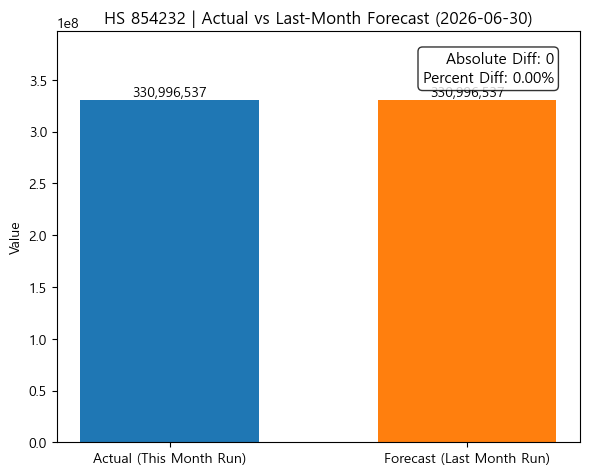

In [7]:

# 전달 run이 내놓았던 '그 달'의 값과, 이제 확정된 실적을 비교합니다.
common_dates = this_month_series.index.intersection(last_month_series.index)
COMPARE_DATE = last_month_fc_pivot.index.min() if not last_month_fc_pivot.empty else LAST_ACTUAL_DATE
# 전달 run이 예측했던 첫 달 = 이번달 run 기준으로는 이미 실적으로 확정된 달인 경우가 일반적
if COMPARE_DATE not in this_month_series.index:
    COMPARE_DATE = common_dates.max() if len(common_dates) else LAST_ACTUAL_DATE

actual   = this_month_series.get(COMPARE_DATE, np.nan)   # 이번달 run 기준(실적으로 확정)
forecast = last_month_series.get(COMPARE_DATE, np.nan)   # 전달 run이 예측했던 값

abs_diff = abs(actual - forecast) if pd.notna(actual) and pd.notna(forecast) else np.nan
pct_diff = (abs_diff / actual * 100) if actual not in (0, None) and pd.notna(abs_diff) else float('nan')

labels = ['Actual (This Month Run)', 'Forecast (Last Month Run)']
values = [actual, forecast]

plt.figure(figsize=(6, 5))
bars = plt.bar(labels, values, color=['#1f77b4', '#ff7f0e'], width=0.6)
plt.ylabel('Value')
plt.title(f'HS {TARGET_HSCODE} | Actual vs Last-Month Forecast ({pd.Timestamp(COMPARE_DATE).date()})')
plt.ylim(0, max(v for v in values if pd.notna(v)) * 1.2)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h, f'{h:,.0f}',
             ha='center', va='bottom', fontsize=10)
textstr = f'Absolute Diff: {abs_diff:,.0f}\nPercent Diff: {pct_diff:.2f}%'
plt.text(0.95, 0.95, textstr, transform=plt.gca().transAxes, fontsize=11,
         verticalalignment='top', horizontalalignment='right',
         bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
plt.tight_layout()
plt.show()


## ⑤ 전달 예측 vs 이번달 예측 비교 (같은 미래 구간)

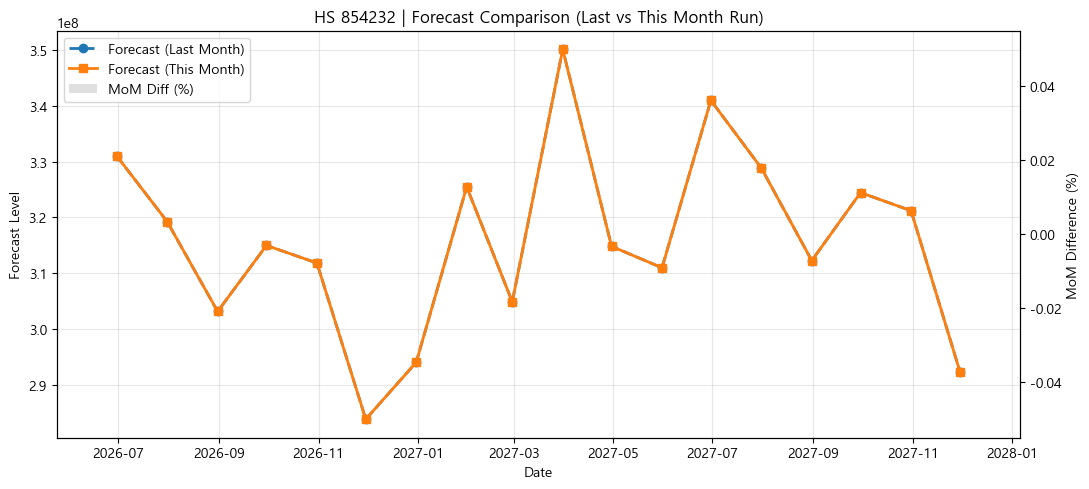

hs_code,Forecast (Last Month),Forecast (This Month),MoM Diff (%)
date_month_end,,,
2026-06-30,3.309965e+08,3.309965e+08,0.0
2026-07-31,3.192607e+08,3.192607e+08,0.0
2026-08-31,3.032082e+08,3.032082e+08,0.0
2026-09-30,3.150021e+08,3.150021e+08,0.0
2026-10-31,3.118630e+08,3.118630e+08,0.0
2026-11-30,2.839542e+08,2.839542e+08,0.0
2026-12-31,2.941209e+08,2.941209e+08,0.0
2027-01-31,3.254622e+08,3.254622e+08,0.0
2027-02-28,3.049328e+08,3.049328e+08,0.0


In [8]:

# FORECAST_START~END 구간에서 전달 run 대비 이번달 run 예측이 얼마나 바뀌었는지 비교
last_win = (last_month_fc_pivot.loc[FORECAST_START:FORECAST_END, [TARGET_HSCODE]]
            .rename(columns={TARGET_HSCODE: 'Forecast (Last Month)'}).sort_index()
            if TARGET_HSCODE in last_month_fc_pivot.columns else pd.DataFrame())
this_win = (this_month_fc_pivot.loc[FORECAST_START:FORECAST_END, [TARGET_HSCODE]]
            .rename(columns={TARGET_HSCODE: 'Forecast (This Month)'}).sort_index()
            if TARGET_HSCODE in this_month_fc_pivot.columns else pd.DataFrame())

df_plot = last_win.join(this_win, how='outer')
df_plot['MoM Diff (%)'] = (
    (df_plot['Forecast (This Month)'] - df_plot['Forecast (Last Month)'])
    / df_plot['Forecast (Last Month)']
) * 100

fig, ax1 = plt.subplots(figsize=(11, 5))
ax1.plot(df_plot.index, df_plot['Forecast (Last Month)'],
         linestyle='--', marker='o', linewidth=2, label='Forecast (Last Month)')
ax1.plot(df_plot.index, df_plot['Forecast (This Month)'],
         linestyle='-', marker='s', linewidth=2, label='Forecast (This Month)')
ax1.set_xlabel('Date'); ax1.set_ylabel('Forecast Level'); ax1.grid(True, alpha=0.3)

ax2 = ax1.twinx()
ax2.bar(df_plot.index, df_plot['MoM Diff (%)'], color='gray', alpha=0.25, width=20,
        label='MoM Diff (%)')
ax2.set_ylabel('MoM Difference (%)')

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.title(f'HS {TARGET_HSCODE} | Forecast Comparison (Last vs This Month Run)')
plt.tight_layout(); plt.show()

df_plot


## ⑥ YoY 수출증가율의 "변화(가속/둔화)" 분석
같은 미래 대상월/대상분기에 대해, 전달 run과 이번달 run의 YoY 증가율을 비교합니다.


[비교 대상 run] 전달: 2026-07-23   vs   이번달: 2026-07-24   |  HS: 854232

[표1] 월별 YoY 수출증가율 변화 (HS 854232)


,old_yoy(%),recent_yoy(%),diff(%p)
date,,,
2026-06-30,15.59,15.59,0.0
2026-07-31,42.18,42.18,0.0
2026-08-31,68.80,68.80,0.0
2026-09-30,71.72,71.72,0.0
2026-10-31,51.87,51.87,0.0
2026-11-30,34.05,34.05,0.0
2026-12-31,32.83,32.83,0.0
2027-01-31,13.87,13.87,0.0
2027-02-28,-5.85,-5.85,0.0


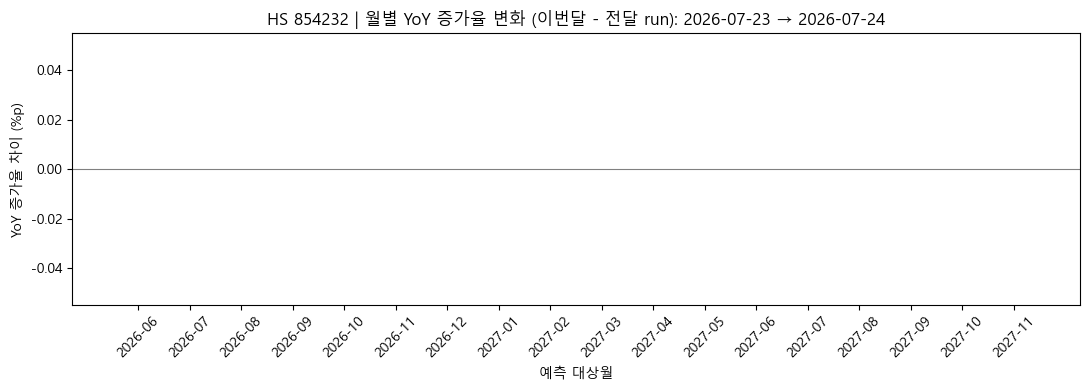


[표2] 분기별 YoY 수출증가율 변화 (HS 854232)


,old_quarterly_yoy(%),recent_quarterly_yoy(%),diff(%p)
date,,,
2026-06-30,24.70,24.70,0.0
2026-09-30,59.54,59.54,0.0
2026-12-31,39.36,39.36,0.0
2027-03-31,-0.37,-0.37,0.0
2027-06-30,2.59,2.59,0.0
2027-09-30,3.00,3.00,0.0
2027-12-31,-31.04,-31.04,0.0


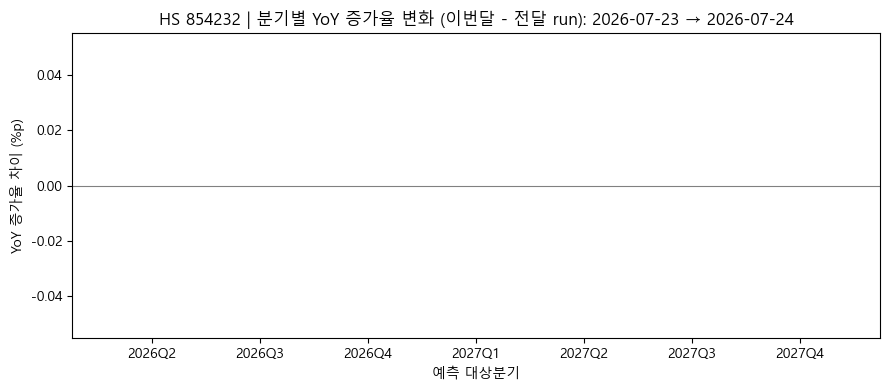


월별 평균 변화: +0.00%p → 변화 없음
분기별 평균 변화: +0.00%p → 변화 없음


In [9]:

old_v, recent_v = LAST_MONTH_VINTAGE, THIS_MONTH_VINTAGE
hs = TARGET_HSCODE
print(f"[비교 대상 run] 전달: {old_v}   vs   이번달: {recent_v}   |  HS: {hs}")

old_combined    = last_month_series
recent_combined = this_month_series
old_fc_dates    = last_month_fc_pivot.index if TARGET_HSCODE in last_month_fc_pivot.columns else pd.DatetimeIndex([])
recent_fc_dates = this_month_fc_pivot.index if TARGET_HSCODE in this_month_fc_pivot.columns else pd.DatetimeIndex([])

if len(old_fc_dates) == 0 or len(recent_fc_dates) == 0:
    raise ValueError(f"HS {hs}에 대해 LAST_MONTH_VINTAGE 또는 THIS_MONTH_VINTAGE 시점의 예측 데이터가 없습니다.")

# ============================================================
# [표1] 월별 YoY 수출증가율 변화
# ============================================================
old_yoy    = old_combined.pct_change(12) * 100
recent_yoy = recent_combined.pct_change(12) * 100

common_months = old_fc_dates.intersection(recent_fc_dates).sort_values()

table1 = pd.DataFrame({
    "date": common_months,
    "old_yoy(%)": old_yoy.reindex(common_months).values,
    "recent_yoy(%)": recent_yoy.reindex(common_months).values,
})
table1["diff(%p)"] = table1["recent_yoy(%)"] - table1["old_yoy(%)"]
table1 = table1.set_index("date")

print(f"\n[표1] 월별 YoY 수출증가율 변화 (HS {hs})")
display(table1.round(2))

fig, ax = plt.subplots(figsize=(11, 4))
colors = ["#2ca02c" if v >= 0 else "#d62728" for v in table1["diff(%p)"]]
ax.bar(table1.index.strftime("%Y-%m"), table1["diff(%p)"], color=colors)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title(f"HS {hs} | 월별 YoY 증가율 변화 (이번달 - 전달 run): {old_v} → {recent_v}")
ax.set_xlabel("예측 대상월")
ax.set_ylabel("YoY 증가율 차이 (%p)")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# ============================================================
# [표2] 분기별(합산 기준) YoY 수출증가율 변화
# ============================================================
def quarterly_yoy_for_vintage(monthly_combined, fc_dates):
    q_sum = monthly_combined.resample("QE").sum()
    q_yoy = q_sum.pct_change(4) * 100
    fc_quarter_ends = pd.to_datetime(fc_dates).to_period("Q").end_time.normalize().unique()
    return q_yoy, pd.DatetimeIndex(fc_quarter_ends)

old_qyoy, old_fc_q       = quarterly_yoy_for_vintage(old_combined, old_fc_dates)
recent_qyoy, recent_fc_q = quarterly_yoy_for_vintage(recent_combined, recent_fc_dates)

common_quarters = old_fc_q.intersection(recent_fc_q).sort_values()

table2 = pd.DataFrame({
    "date": common_quarters,
    "old_quarterly_yoy(%)": old_qyoy.reindex(common_quarters).values,
    "recent_quarterly_yoy(%)": recent_qyoy.reindex(common_quarters).values,
})
table2["diff(%p)"] = table2["recent_quarterly_yoy(%)"] - table2["old_quarterly_yoy(%)"]
table2 = table2.set_index("date")

print(f"\n[표2] 분기별 YoY 수출증가율 변화 (HS {hs})")
display(table2.round(2))

fig, ax = plt.subplots(figsize=(9, 4))
colors2 = ["#2ca02c" if v >= 0 else "#d62728" for v in table2["diff(%p)"]]
ax.bar(table2.index.to_period("Q").astype(str), table2["diff(%p)"], color=colors2)
ax.axhline(0, color="gray", linewidth=0.8)
ax.set_title(f"HS {hs} | 분기별 YoY 증가율 변화 (이번달 - 전달 run): {old_v} → {recent_v}")
ax.set_xlabel("예측 대상분기")
ax.set_ylabel("YoY 증가율 차이 (%p)")
plt.tight_layout()
plt.show()

# ============================================================
# 해석 힌트
# ============================================================
accel_month = table1["diff(%p)"].mean()
accel_q     = table2["diff(%p)"].mean()
dir_m = "가속(상향 수정)" if accel_month > 0 else ("둔화(하향 수정)" if accel_month < 0 else "변화 없음")
dir_q = "가속(상향 수정)" if accel_q > 0 else ("둔화(하향 수정)" if accel_q < 0 else "변화 없음")
print(f"\n월별 평균 변화: {accel_month:+.2f}%p → {dir_m}")
print(f"분기별 평균 변화: {accel_q:+.2f}%p → {dir_q}")


## ⑦ 최근 N년 실적 + 향후 예측 결합 → YoY 성장률의 "가속도"(월별 차분) 전체 흐름
이번달 run의 실적+예측 연속 시계열을 사용합니다. YoY 성장률을 구한 뒤,
그 YoY를 다시 한 번 전월대비 차분(diff)하면 "성장률 자체가 빨라지고 있는지/느려지고 있는지"를 볼 수 있습니다.



[최근 5년 + 예측] YoY 성장률 및 가속도 (HS 854232)


,value,yoy(%),yoy_accel(%p),구간
date_month_end,,,,
2024-12-31,1.482752e+08,6.80,-2.66,실적
2025-01-31,1.939045e+08,14.94,8.14,실적
2025-02-28,1.785929e+08,1.97,-12.97,실적
2025-03-31,2.187676e+08,11.59,9.62,실적
2025-04-30,2.383615e+08,42.63,31.04,실적
2025-05-31,2.310284e+08,39.64,-2.99,실적
2025-06-30,2.863431e+08,95.07,55.42,실적
2025-07-31,2.245471e+08,19.86,-75.21,실적
2025-08-31,1.796291e+08,33.03,13.17,실적


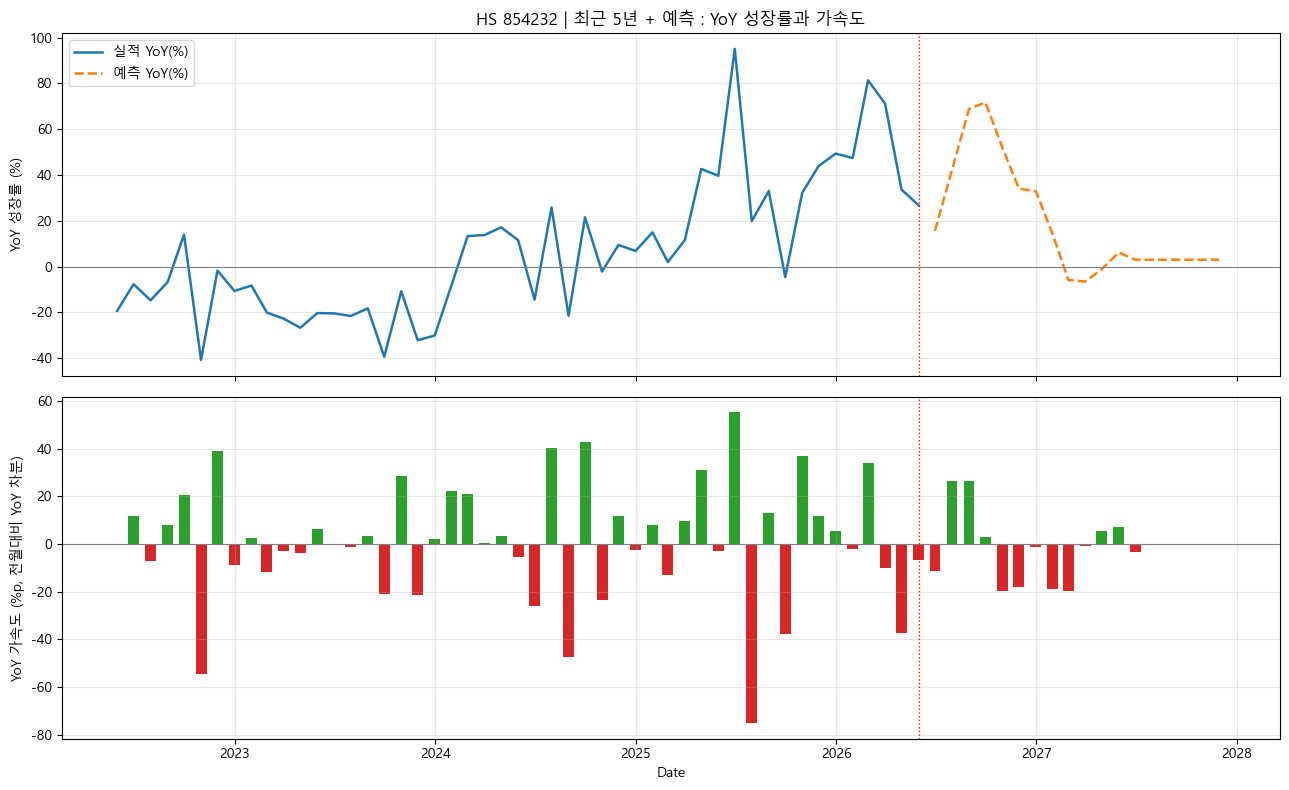


[참고] YoY 상위 10% 급등/급락 구간 (|YoY| >= 48.2%) → 기저효과 점검 후보


,value,base_12m_ago,yoy(%),yoy_accel(%p),구간
date_month_end,,,,,
2025-06-30,2.863431e+08,146793475.0,95.07,55.42,실적
2025-12-31,2.214210e+08,148275229.0,49.33,5.39,실적
2026-02-28,3.238647e+08,178592939.0,81.34,33.94,실적
2026-03-31,3.744463e+08,218767622.0,71.16,-10.18,실적
2026-08-31,3.032082e+08,179629065.0,68.80,26.62,예측
2026-09-30,3.150021e+08,183436884.0,71.72,2.93,예측
2026-10-31,3.118630e+08,205352272.0,51.87,-19.86,예측


In [10]:

HIST_YEARS_FOR_ACCEL = 5  # 최근 몇 년치 실적을 사용할지

accel_base_date = LAST_ACTUAL_DATE - pd.DateOffset(years=HIST_YEARS_FOR_ACCEL)
accel_series = recent_combined.loc[recent_combined.index >= accel_base_date].sort_index()

accel_yoy = accel_series.pct_change(12) * 100
accel_yoy_diff = accel_yoy.diff(1)

accel_df = pd.DataFrame({
    "value": accel_series,
    "yoy(%)": accel_yoy,
    "yoy_accel(%p)": accel_yoy_diff,
})
accel_df["구간"] = ["실적" if d <= LAST_ACTUAL_DATE else "예측" for d in accel_df.index]

print(f"\n[최근 {HIST_YEARS_FOR_ACCEL}년 + 예측] YoY 성장률 및 가속도 (HS {hs})")
display(accel_df.round(2).tail(36))

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(13, 8), sharex=True)

is_actual = accel_df.index <= LAST_ACTUAL_DATE
ax1.plot(accel_df.index[is_actual], accel_df["yoy(%)"][is_actual],
          color="#1f77b4", linewidth=1.8, label="실적 YoY(%)")
ax1.plot(accel_df.index[~is_actual], accel_df["yoy(%)"][~is_actual],
          color="#ff7f0e", linewidth=1.8, linestyle="--", label="예측 YoY(%)")
ax1.axhline(0, color="gray", linewidth=0.8)
ax1.axvline(LAST_ACTUAL_DATE, color="red", linestyle=":", linewidth=1)
ax1.set_ylabel("YoY 성장률 (%)")
ax1.set_title(f"HS {hs} | 최근 {HIST_YEARS_FOR_ACCEL}년 + 예측 : YoY 성장률과 가속도")
ax1.legend(loc="upper left")
ax1.grid(True, alpha=0.3)

colors3 = ["#2ca02c" if v >= 0 else "#d62728" for v in accel_df["yoy_accel(%p)"]]
ax2.bar(accel_df.index, accel_df["yoy_accel(%p)"], color=colors3, width=20)
ax2.axhline(0, color="gray", linewidth=0.8)
ax2.axvline(LAST_ACTUAL_DATE, color="red", linestyle=":", linewidth=1)
ax2.set_ylabel("YoY 가속도 (%p, 전월대비 YoY 차분)")
ax2.set_xlabel("Date")
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ============================================================
# 기저효과(베이스 이펙트) 후보 구간 탐지 (참고용 휴리스틱)
# ============================================================
threshold = accel_df["yoy(%)"].abs().quantile(0.90)
flagged = accel_df[accel_df["yoy(%)"].abs() >= threshold].copy()
flagged["base_12m_ago"] = accel_series.shift(12).reindex(flagged.index)

if len(flagged) > 0:
    print(f"\n[참고] YoY 상위 10% 급등/급락 구간 (|YoY| >= {threshold:.1f}%) → 기저효과 점검 후보")
    display(flagged[["value", "base_12m_ago", "yoy(%)", "yoy_accel(%p)", "구간"]].round(2))
else:
    print("\n[참고] 뚜렷한 급등/급락 구간이 발견되지 않았습니다.")


## ⑧ 실적(실선) + 예측(점선) 연속 차트

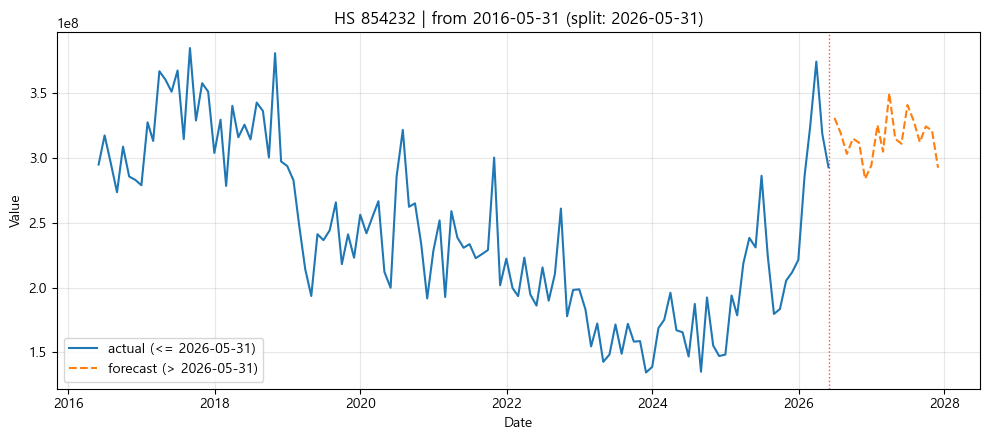

In [11]:

def plot_series_split(series: pd.Series, split_date, n_months: int, title: str,
                       save_path: str | None = None, show: bool = True):
    """단일 Series를 split_date 기준 실선(<=)/점선(>)으로 분할 시각화."""
    c = pd.to_datetime(split_date)
    start = c - pd.DateOffset(months=n_months)
    sub = series.loc[series.index >= start].sort_index()
    left = sub.loc[sub.index <= c]
    right = sub.loc[sub.index > c]

    plt.figure(figsize=(10, 4.5))
    plt.plot(left.index, left.values, label=f"actual (<= {c.date()})", linewidth=1.5)
    if not right.empty:
        plt.plot(right.index, right.values, linestyle="--",
                  label=f"forecast (> {c.date()})", linewidth=1.5)
    plt.axvline(c, color='red', linestyle=":", linewidth=1, alpha=0.7)
    plt.title(title)
    plt.xlabel("Date"); plt.ylabel("Value")
    plt.legend(); plt.grid(True, alpha=0.3)
    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, dpi=180, bbox_inches="tight")
    if show:
        plt.show()
    else:
        plt.close()


plot_series_split(
    this_month_series, SPLIT_DATE, HIST_MONTHS,
    title=f"HS {TARGET_HSCODE} | from {(pd.to_datetime(SPLIT_DATE) - pd.DateOffset(months=HIST_MONTHS)).date()} (split: {pd.to_datetime(SPLIT_DATE).date()})",
)


## ⑨ HS 코드별 데이터 저장

In [12]:

import os
from pathlib import Path
from datetime import datetime

EXPORT_DIR = Path(os.environ.get("EXPORT_DIR_OVERRIDE", str(Path.home() / "reports" / "us_export_data")))
EXPORT_DIR.mkdir(parents=True, exist_ok=True)
print(f"[저장 경로] {EXPORT_DIR}")

today_str = datetime.today().strftime('%Y%m%d')


def save_hscode_data(df, hscode, n_periods=28, save_excel=True, save_csv=True):
    """특정 HS 코드의 최근 데이터를 파일로 저장 (df: index=date, columns=hs_code인 wide 테이블)"""
    if hscode not in df.columns:
        print(f"[SKIP] {hscode} : 데이터프레임에 존재하지 않는 HS 코드")
        return

    data = df[[hscode]].tail(n_periods).copy()
    data.index.name = 'date'

    base_name = f'us_hscode_{hscode}_{today_str}'

    if save_excel:
        xlsx_path = EXPORT_DIR / (base_name + '.xlsx')
        data.to_excel(xlsx_path)
        print(f"[저장 완료] {xlsx_path}")

    if save_csv:
        csv_path = EXPORT_DIR / (base_name + '.csv')
        data.to_csv(csv_path, encoding='utf-8-sig')
        print(f"[저장 완료] {csv_path}")


# (1) 단일 HS 코드 저장
save_hscode_data(trade_total_df, TARGET_HSCODE, n_periods=60)

# (2) 여러 HS 코드 일괄 저장이 필요한 경우
# hscode_list = ['854232', '870380', '271012']
# for hs in hscode_list:
#     save_hscode_data(trade_total_df, hs, n_periods=28)

# (3) 전체 HS 코드를 각각 저장하려면
# for hs in trade_total_df.columns:
#     save_hscode_data(trade_total_df, hs, n_periods=28)


[저장 경로] C:\Users\82108\reports\us_export_data
[저장 완료] C:\Users\82108\reports\us_export_data\us_hscode_854232_20260724.xlsx
[저장 완료] C:\Users\82108\reports\us_export_data\us_hscode_854232_20260724.csv


## ⑩ 대상 HS 코드 전체 시계열(실적+예측) 조회

In [13]:

trade_total_df[[TARGET_HSCODE]].tail(36)


hs_code,854232
date_month_end,
2024-12-31,1.482752e+08
2025-01-31,1.939045e+08
2025-02-28,1.785929e+08
2025-03-31,2.187676e+08
2025-04-30,2.383615e+08
2025-05-31,2.310284e+08
2025-06-30,2.863431e+08
2025-07-31,2.245471e+08
2025-08-31,1.796291e+08


## ⑪ [제한사항] 상품 단가(가격) 분석 — 현재 미국 데이터로는 실행 불가

한국 버전은 `korea_monthly_trade_data`에 수출중량(weight) indicator가 함께 저장되어 있어
`수출금액 ÷ 수출중량 = 평균 단가`를 바로 계산할 수 있었습니다.

미국 쪽 수집 파이프라인(`us_export_data_collect_v3.py`)은 Census API의 `ALL_VAL_MO`(금액)만 수집하고
있어 **수출중량/수량 데이터가 DB에 없습니다.** 따라서 이 섹션은 지금은 실행할 수 없습니다.

필요하시면:
1. Census HS 수출 API에는 수량 필드(예: `QTY_1_MO`, `UNIT_QY1`)가 별도로 존재하므로,
   V3 수집기의 `get=` 파라미터에 이를 추가해 별도 컬럼(또는 별도 테이블)으로 수집하고,
2. 그 뒤 아래와 유사한 형태로 단가 계산 함수를 이 노트북에 추가하면 한국 버전과 동일하게 재현할 수 있습니다.

```python
# (수량 데이터가 확보된 이후 사용할 수 있는 스텁 예시 — 지금은 실행하지 마세요)
# price_df = pd.DataFrame({
#     "export_value": trade_total_df[TARGET_HSCODE],
#     "export_qty":   qty_df[TARGET_HSCODE],   # 아직 존재하지 않는 데이터
# }).dropna()
# price_df = price_df[price_df["export_qty"] > 0]
# price_df["unit_price"] = price_df["export_value"] / price_df["export_qty"]
# price_df["price_yoy(%)"] = price_df["unit_price"].pct_change(12) * 100
# price_df["price_yoy_accel(%p)"] = price_df["price_yoy(%)"].diff(1)
```
